In [1]:
import os
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
train_path = "../Data/train"

data = []

for label in ["men", "women"]:
    folder_path = os.path.join(train_path, label)
    image_paths = glob(os.path.join(folder_path, "*.jpg"))

    for image_path in image_paths:
        data.append({
            "path": image_path,
            "label": label
        })

df = pd.DataFrame(data)
df.head()

,path,label
0,../Data/train\men\0.jpg,men
1,../Data/train\men\1.jpg,men
2,../Data/train\men\10.jpg,men
3,../Data/train\men\100.jpg,men
4,../Data/train\men\101.jpg,men


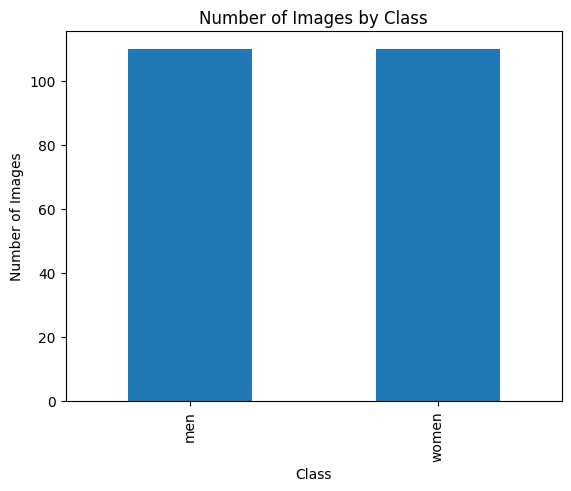

In [3]:
df["label"].value_counts()
df["label"].value_counts().plot(kind="bar")
plt.title("Number of Images by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

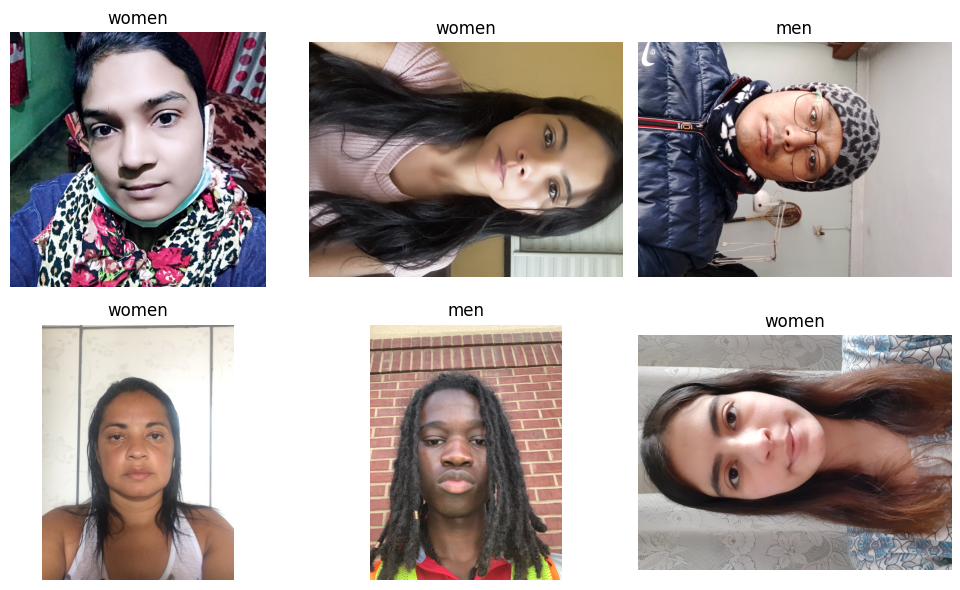

In [4]:
sample_df = df.sample(6, random_state=42)

plt.figure(figsize=(10, 6))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.path)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
image_info = []

for row in df.itertuples():
    img = Image.open(row.path)
    width, height = img.size
    
    image_info.append({
        "path": row.path,
        "label": row.label,
        "width": width,
        "height": height
    })

image_df = pd.DataFrame(image_info)

image_df.head()

,path,label,width,height
0,../Data/train\men\0.jpg,men,2448,2448
1,../Data/train\men\1.jpg,men,2448,3264
2,../Data/train\men\10.jpg,men,5472,7296
3,../Data/train\men\100.jpg,men,4608,3456
4,../Data/train\men\101.jpg,men,6560,4920


In [6]:
image_df[["width", "height"]].describe()

,width,height
count,220.000000,220.000000
mean,2654.509091,2893.481818
std,1055.842158,1153.336935
min,480.000000,480.000000
25%,1944.000000,2448.000000
50%,2448.000000,2592.000000
75%,3264.000000,3264.000000
max,6560.000000,7296.000000


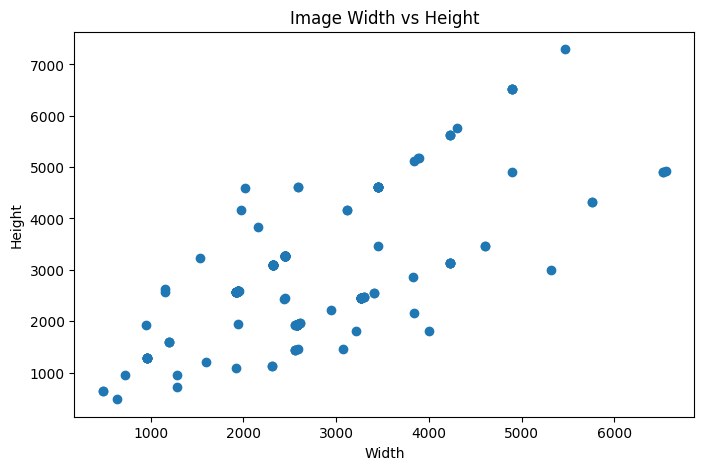

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(image_df["width"], image_df["height"])
plt.title("Image Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

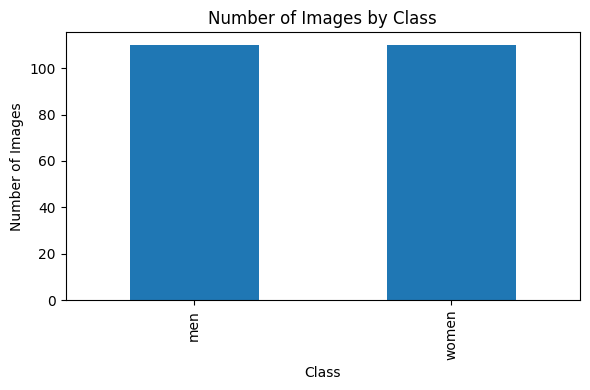

In [8]:
plt.figure(figsize=(6, 4))
df["label"].value_counts().plot(kind="bar")
plt.title("Number of Images by Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig("../charts/class_distribution.png")
plt.show()

In [9]:
from PIL import Image, ImageOps

img = Image.open(row.path)
img = ImageOps.exif_transpose(img)

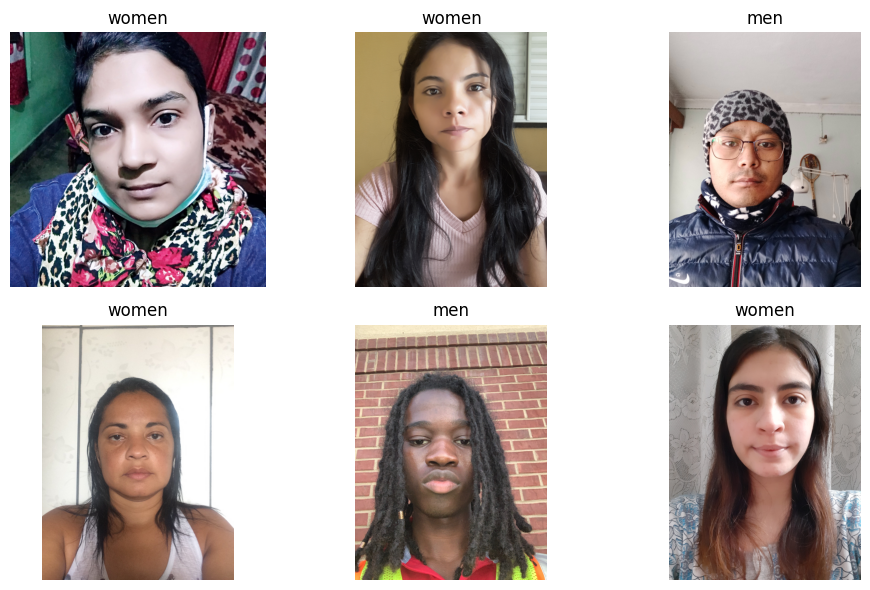

In [10]:
from PIL import Image, ImageOps

sample_df = df.sample(6, random_state=42)

plt.figure(figsize=(10, 6))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.path)
    img = ImageOps.exif_transpose(img)

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(row.label)
    plt.axis("off")

plt.tight_layout()
plt.savefig("../charts/sample_images.png")
plt.show()

## Image Preprocessing

In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import ImageOps

In [12]:
train_dir = "../Data/train"
test_dir = "../Data/test"

In [13]:
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img).convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Lambda(lambda img: ImageOps.exif_transpose(img).convert("RGB")),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=test_transform
)

train_dataset.class_to_idx

{'men': 0, 'women': 1}

In [14]:
train_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Labels:", labels)

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [15]:
train_dataset.class_to_idx

{'men': 0, 'women': 1}

In [16]:
from collections import Counter

Counter(train_dataset.targets)

Counter({0: 110, 1: 110})

In [ ]:
Counter({0: 110, 1: 110})

val_size = int(0.2 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(

    train_dataset,    break

    batch_size=16,    print(labels)

    shuffle=Truefor images, labels in train_loader:

)

)

val_loader = DataLoader(    shuffle=False

    val_dataset,    batch_size=16,

tensor([1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1])


In [18]:
#Check whether it is shuffled properly one more time
for images, labels in train_loader:
    print(labels)
    break

tensor([0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])


## Baseline CNN Model

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

In [20]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Training the Baseline CNN

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 10

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # 1. Clear old gradients
        optimizer.zero_grad()
        
        # 2. Forward pass: model makes predictions
        outputs = model(images)
        
        # 3. Calculate loss
        loss = criterion(outputs, labels)
        
        # 4. Backward pass: calculate gradients
        loss.backward()
        
        # 5. Update model weights
        optimizer.step()
        
        # Track loss
        running_loss += loss.item()
        
        # Track accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    )

    model.eval()        f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}"

    val_running_loss = 0.0        f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_accuracy:.4f}, "

    val_correct = 0        f"Epoch [{epoch+1}/{num_epochs}], "

    val_total = 0    print(

    

    with torch.no_grad():    val_accuracies.append(epoch_val_accuracy)

        for images, labels in val_loader:    val_losses.append(epoch_val_loss)

            images = images.to(device)

            labels = labels.to(device)    epoch_val_accuracy = val_correct / val_total

    epoch_val_loss = val_running_loss / len(val_loader)

            outputs = model(images)

            loss = criterion(outputs, labels)            val_correct += (predicted == labels).sum().item()

            val_total += labels.size(0)

            val_running_loss += loss.item()            _, predicted = torch.max(outputs, 1)

Epoch [1/10], Loss: 0.7384, Accuracy: 0.5000
Epoch [2/10], Loss: 0.6547, Accuracy: 0.6000
Epoch [3/10], Loss: 0.5674, Accuracy: 0.7045
Epoch [4/10], Loss: 0.5583, Accuracy: 0.7091
Epoch [5/10], Loss: 0.4938, Accuracy: 0.7818
Epoch [6/10], Loss: 0.3948, Accuracy: 0.8273
Epoch [7/10], Loss: 0.4038, Accuracy: 0.8273
Epoch [8/10], Loss: 0.3289, Accuracy: 0.8545
Epoch [9/10], Loss: 0.3599, Accuracy: 0.8455
Epoch [10/10], Loss: 0.2178, Accuracy: 0.9227


## Evaluating the Baseline CNN

In [25]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy:.4f}")

Test Accuracy: 0.8125


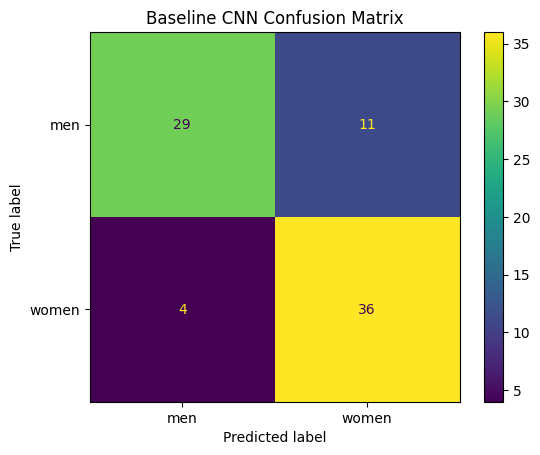

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_dataset.classes
)

disp.plot()
plt.title("Baseline CNN Confusion Matrix")
plt.show()

In [27]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

         men       0.88      0.72      0.79        40
       women       0.77      0.90      0.83        40

    accuracy                           0.81        80
   macro avg       0.82      0.81      0.81        80
weighted avg       0.82      0.81      0.81        80



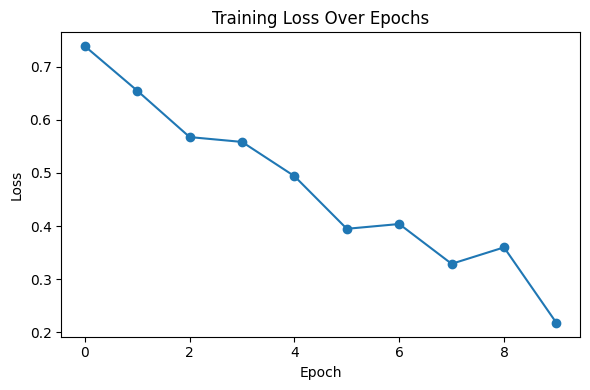

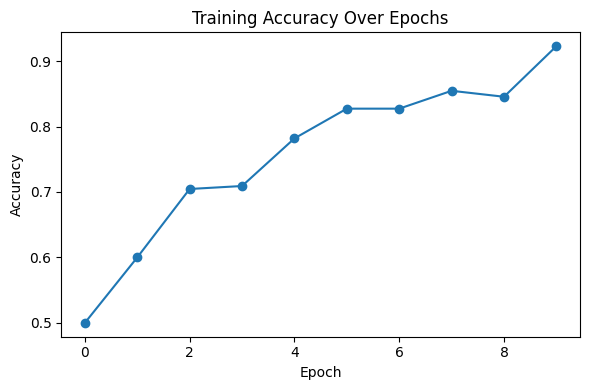

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o", label="Train Loss")
plt.plot(val_losses, marker="o", label="Val Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("../charts/baseline_training_validation_loss.png")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(train_accuracies, marker="o", label="Train Accuracy")
plt.plot(val_accuracies, marker="o", label="Val Accuracy")
plt.title("Training and Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()plt.show()

plt.tight_layout()plt.savefig("../charts/baseline_training_validation_accuracy.png")

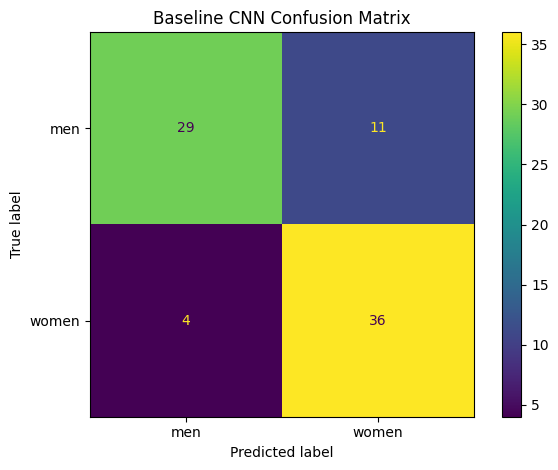

In [29]:
disp.plot()
plt.title("Baseline CNN Confusion Matrix")
plt.tight_layout()
plt.savefig("../charts/baseline_confusion_matrix.png")
plt.show()